# Use the CIEMAT/NIST model (system with 2 PMTs)

In [1]:
pip install TDCRPy==2.20.7

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
Rad="Ni-63"                   # radionuclides
kB =1.0e-5                  # Birks constant in cm keV-1
V = 10                      # volume of scintillator in mL
ne = 1000                   # number of discretization steps for the numerical computation of the quenching function
L = np.logspace(-1,2,50)    # vector of free parameters
nq = td.TDCR_model_lib.readParameters()[14][0] # get the quantum efficiency

## Analytical model (precise but less accurated for complex decay schemes)

In [4]:
eff_D = []
td.TDCR_model_lib.modelAnalyticalCN(0.1, "Ni-63", 1e-5, 10, 100)
for l in L:
    print(l)
    result1 = td.TDCR_model_lib.modelAnalyticalCN(float(l), Rad, kB, V, ne)
    eff_D.append(result1[2])

0.1
0.11513953993264472
0.13257113655901093
0.15264179671752334
0.1757510624854792
0.20235896477251572
0.2329951810515372
0.2682695795279726
0.3088843596477481
0.35564803062231287
0.40949150623804254
0.47148663634573934
0.5428675439323859
0.6250551925273973
0.7196856730011519
0.8286427728546845


0.9540954763499939
1.0985411419875584
1.2648552168552958
1.4563484775012436
1.6768329368110082
1.9306977288832496
2.2229964825261943
2.5595479226995357
2.9470517025518097
3.393221771895328
3.906939937054617
4.498432668969446
5.17947467923121
5.963623316594643
6.8664884500430015


7.906043210907698
9.102981779915218
10.481131341546853
12.067926406393289
13.894954943731374
15.998587196060573
18.420699693267164
21.209508879201906
24.420530945486497
28.11768697974231
32.374575428176435
37.27593720314938
42.91934260128778
49.417133613238335
56.89866029018293


65.51285568595509
75.43120063354615


86.85113737513521
100.0


## Stochastic model (less precise but aimed to be more accurate for complex decay schemes)

In [5]:
N = 1000 # number of Monte-Carlo trials
eff_D2, u_eff_D2 = [], []
td.TDCRPy.TDCRPy(L[0], Rad, "1", N, kB, V, "eff", barp=True, record=True)
for l in L:
    result2 = td.TDCRPy.TDCRPy(l, Rad, "1", N, kB, V, "eff", readRecHist=True)
    eff_D2.append(result2[12])
    u_eff_D2.append(result2[13])


 ______  ______  ______ _______  ________
|__  __||  ___ \|  ___||  ___ | |  ____ |
  | |   | |  | || |    | |  | | | |___| |___     ___
  | |   | |  | || |    | |__| | |  _____|\  \   |  |
  | |   | |__| || |____|  __  \ | |       \  \  |  |
  |_|   |_____/ |_____||_|  \__\|_|        \  \_|  |
  +++++++++++++++++++++++++++++++++++++++++/      /
  ________________________________________/      /
 |______________________________________________/     


version 2.20.7
BIPM 2023 - license MIT 
distribution: https://pypi.org/project/TDCRPy 
developement: https://github.com/RomainCoulon/TDCRPy 

start calculation...


Processing:   0%|          | 0/1000 [00:00<?, ? decays/s]

Processing:   5%|▍         | 46/1000 [00:00<00:02, 455.95 decays/s]

Processing:  10%|▉         | 97/1000 [00:00<00:01, 482.77 decays/s]

Processing:  15%|█▌        | 150/1000 [00:00<00:01, 499.94 decays/s]

...

Processing:  85%|████████▌ | 851/1000 [00:01<00:00, 487.28 decays/s]

Processing:  90%|█████████ | 900/1000 [00:01<00:00, 483.87 decays/s]

Processing:  95%|█████████▍| 949/1000 [00:01<00:00, 483.14 decays/s]

Processing: 100%|█████████▉| 999/1000 [00:02<00:00, 485.49 decays/s]

Processing: 100%|██████████| 1000/1000 [00:02<00:00, 483.69 decays/s]

## Results

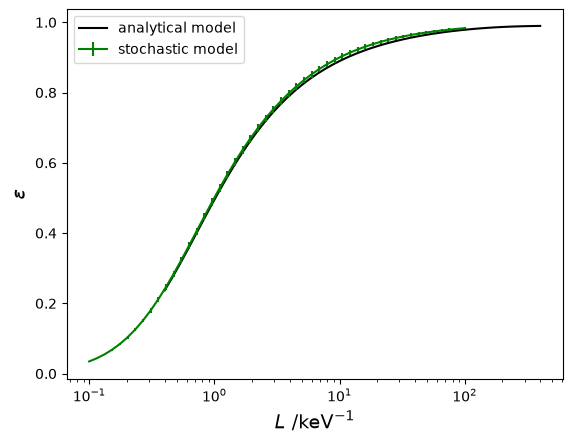

In [6]:
plt.figure("efficiency vs free parameter")
plt.clf()
plt.plot(L/nq,eff_D,"-k",label="analytical model")
plt.errorbar(L,eff_D2,yerr=u_eff_D2,fmt="-g",label="stochastic model")
plt.xscale('log')
plt.xlabel(r'$L$ /keV$^{-1}$', fontsize=14)
plt.ylabel(r'$\epsilon$', fontsize=14)
plt.legend()
